In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
visa_df=pd.read_csv(r"C:\Users\Achyutha\Documents\NareshIT\GenAi\datasets\Visadataset - Visadataset.csv")
cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns


In [2]:
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


**Why Scaling**

- Scaling presreve the numerical statbility across the columns
   Ex: Age:20 salary:50000 Exp:2
   diff columns having the different scale (limit)
   we want to keep all the columns undr same limit
   if we don't keep under scale some ML algo feels salary is the important column
  because of the highest value
so we use scaling concepts in this

**Faster Training**
- some of ML algorithms like **KNN,KMEANS,SVM** are distance bassed algorithms
if we lower the values the calculation are fast
in every model development will do math calculations
in order to increase the fastness(optimization) scallinf is very helpful

**Z-Score**

<img alt="Z-Score Formula" id="dimg_NLB6aoX6Hb2fseMPt77PSQ_35" src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQosHBYyIpBSDNCQxuHga3HaRqr1IpjmfoCxW8zkJPUSQ&amp;s=10" data-csiid="NLB6aoX6Hb2fseMPt77PSQ_28" data-atf="4">

In [5]:
visa_df['prevailing_wage']

0           592.2029
1         83425.6500
2        122996.8600
3         83434.0300
4        149907.3900
            ...     
25475     77092.5700
25476    279174.7900
25477    146298.8500
25478     86154.7700
25479     70876.9100
Name: prevailing_wage, Length: 25480, dtype: float64

In [7]:
wage_data=visa_df['prevailing_wage']
#step-1: wage_mean=wage_data.mean()
#step-2:wage_sd
#step-3:Nr=wage_data-wage_mean
#step-4: Nr/wage_sd


In [9]:
wage_mean=wage_data.mean()
wage_mean

np.float64(74455.81459209183)

In [11]:
wage_sd = visa_df['prevailing_wage'].std()
wage_sd

52815.94232687357

In [12]:
Nr=wage_data-wage_mean
Nr

0        -73863.611692
1          8969.835408
2         48541.045408
3          8978.215408
4         75451.575408
             ...      
25475      2636.755408
25476    204718.975408
25477     71843.035408
25478     11698.955408
25479     -3578.904592
Name: prevailing_wage, Length: 25480, dtype: float64

In [15]:
wage_z=Nr/wage_sd
wage_z

0       -1.398510
1        0.169832
2        0.919060
3        0.169991
4        1.428576
           ...   
25475    0.049923
25476    3.876083
25477    1.360253
25478    0.221504
25479   -0.067762
Name: prevailing_wage, Length: 25480, dtype: float64

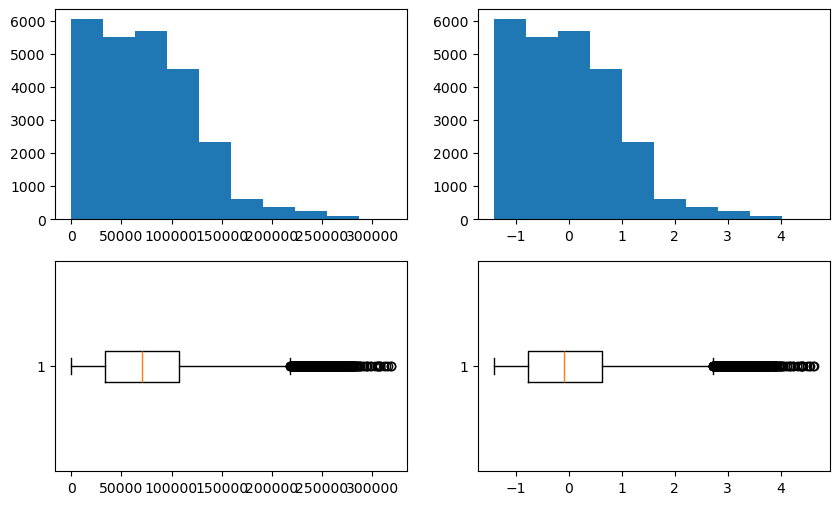

In [20]:
#old data : wage_data
# z_data : wage_z
plt.figure(figsize=(10,6))
plt.subplot(2,2,1).hist(wage_data)
plt.subplot(2,2,2).hist(wage_z)
plt.subplot(2,2,3).boxplot(wage_data,vert=False)
plt.subplot(2,2,4).boxplot(wage_z,vert=False)
plt.show()

In [ ]:
- sklearn
   - preprocessing
      - standard scaler
         - fit transform

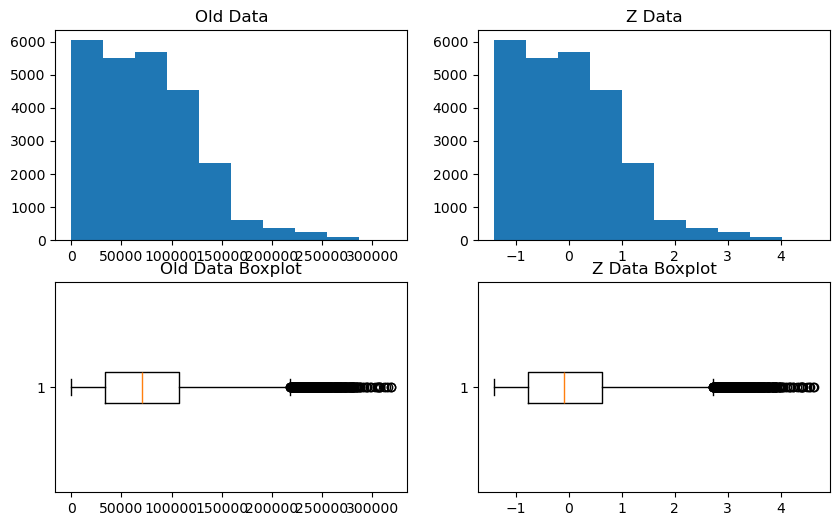

In [21]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Take wage data
wage_data = visa_df[['prevailing_wage']]

# Create StandardScaler object
ss = StandardScaler()

# Apply fit_transform
wage_z = ss.fit_transform(wage_data)

# Plot
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.hist(wage_data)
plt.title('Old Data')

plt.subplot(2,2,2)
plt.hist(wage_z)
plt.title('Z Data')

plt.subplot(2,2,3)
plt.boxplot(wage_data, vert=False)
plt.title('Old Data Boxplot')

plt.subplot(2,2,4)
plt.boxplot(wage_z, vert=False)
plt.title('Z Data Boxplot')

plt.show()

**Normalization**

<img alt="Normalization vs Standardization in Machine Learning: A Deep Dive | by Harsha Vardhan Mannem | Artificial Intelligence in Plain English" id="dimg_sq96ataxAaqphvcPpqDHGQ_433" src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTR79YJYA6QYzfD93P5E4RxNJLDJsw7GEiS6oDoOsmdMA&amp;s=10" data-csiid="sq96ataxAaqphvcPpqDHGQ_56" data-atf="4">

In [22]:
visa_df=pd.read_csv(r"C:\Users\Achyutha\Documents\NareshIT\GenAi\datasets\Visadataset - Visadataset.csv")
cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns

In [23]:
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [24]:
cat,num

(Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
        'requires_job_training', 'region_of_employment', 'unit_of_wage',
        'full_time_position', 'case_status'],
       dtype='object'),
 Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object'))

In [26]:
# step-1: wage_min
# step-2: wage_max
# step-3: Nr=wage_data-wage-min
# step-4: Dr=wage_max-wage_min
#step-5:wage_norm=Nr/Dr


In [28]:
wage_min=visa_df['prevailing_wage'].min()
wage_max=visa_df['prevailing_wage'].max()
Nr=wage_data-wage_min
Dr=wage_max-wage_min
wage_norm=Nr/Dr

In [29]:
wage_norm

,prevailing_wage
0,0.001849
1,0.261345
2,0.385312
3,0.261371
4,0.469616
...,...
25475,0.241505
25476,0.874579
25477,0.458311
25478,0.269895


In [31]:
# standard scalar is called as a Z score
# MinMax Scalar is called as Norm 0 to 1

- Sklearn
  -preprocessing
     - MinMaxScalar
          -fit_transform

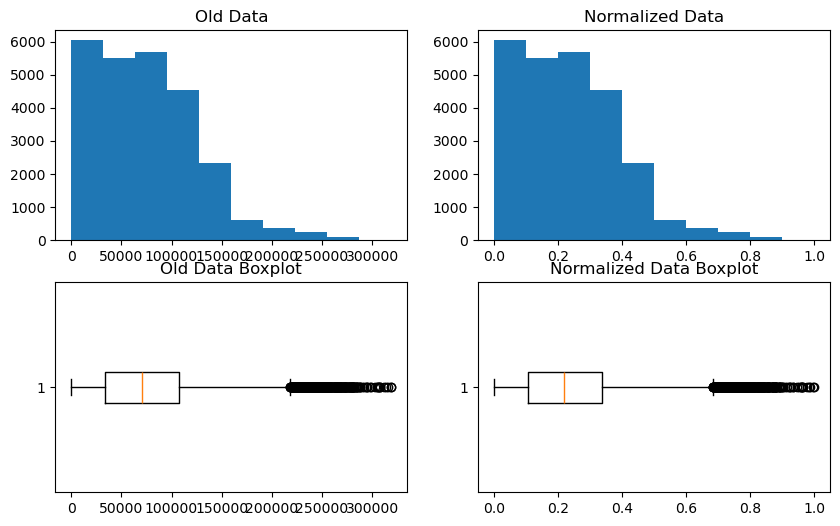

In [33]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Take wage data
wage_data = visa_df[['prevailing_wage']]

# Create MinMaxScaler object
mms = MinMaxScaler()

# Apply fit_transform
wage_norm = mms.fit_transform(wage_data)

# Plot
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.hist(wage_data)
plt.title('Old Data')

plt.subplot(2,2,2)
plt.hist(wage_norm)
plt.title('Normalized Data')

plt.subplot(2,2,3)
plt.boxplot(wage_data, vert=False)
plt.title('Old Data Boxplot')

plt.subplot(2,2,4)
plt.boxplot(wage_norm, vert=False)
plt.title('Normalized Data Boxplot')

plt.show()

In [34]:
from sklearn.preprocessing import MinMaxScaler

wage_data = visa_df[['prevailing_wage']]

mms = MinMaxScaler()

wage_norm = mms.fit_transform(wage_data)

In [35]:
wage_norm

array([[0.00184853],
       [0.2613452 ],
       [0.385312  ],
       ...,
       [0.45831136],
       [0.26989486],
       [0.22203311]], shape=(25480, 1))